In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from sklearn.linear_model import LinearRegression

In [19]:
#df = pd.read_csv("usa_00003.csv.gz")
#df.to_pickle("data.pkl")

In [20]:
data = pd.read_pickle("data.pkl")
print("Columns:",data.columns)
print("Dimensions:", data.shape)
# AI SITE
degfield_map = pd.DataFrame({
    "DEGFIELD": [
        0, 11, 13, 14, 15, 19, 20, 21, 22, 23, 24, 25, 26, 29,
        32, 33, 34, 35, 36, 37, 38, 40, 41, 48, 49, 50, 51, 52,
        53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64
    ],
    "FIELD_NAME": [
        "N/A",
        "Agriculture",
        "Environment and Natural Resources",
        "Architecture",
        "Area, Ethnic, and Civilization Studies",
        "Communications",
        "Communication Technologies",
        "Computer and Information Sciences",
        "Cosmetology Services and Culinary Arts",
        "Education Administration and Teaching",
        "Engineering",
        "Engineering Technologies",
        "Linguistics and Foreign Languages",
        "Family and Consumer Sciences",
        "Law",
        "English Language, Literature, and Composition",
        "Liberal Arts and Humanities",
        "Library Science",
        "Biology and Life Sciences",
        "Mathematics and Statistics",
        "Military Technologies",
        "Interdisciplinary and Multi-Disciplinary Studies (General)",
        "Physical Fitness, Parks, Recreation, and Leisure",
        "Philosophy and Religious Studies",
        "Theology and Religious Vocations",
        "Physical Sciences",
        "Nuclear, Industrial Radiology, and Biological Technologies",
        "Psychology",
        "Criminal Justice and Fire Protection",
        "Public Affairs, Policy, and Social Work",
        "Social Sciences",
        "Construction Services",
        "Electrical and Mechanic Repairs and Technologies",
        "Precision Production and Industrial Arts",
        "Transportation Sciences and Technologies",
        "Fine Arts",
        "Medical and Health Sciences and Services",
        "Business",
        "History"
    ]
})
data  = data.merge(degfield_map, how = "left", on = "DEGFIELD")
data = data[ ~(data['DEGFIELD'].isin([0,38]))] 


Columns: Index(['YEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STRATA',
       'GQ', 'PERNUM', 'PERWT', 'SEX', 'AGE', 'RACE', 'RACED', 'EDUC', 'EDUCD',
       'DEGFIELD', 'DEGFIELDD', 'DEGFIELD2', 'DEGFIELD2D', 'EMPSTAT',
       'EMPSTATD', 'LABFORCE', 'INCWAGE'],
      dtype='str')
Dimensions: (81623947, 24)


In [21]:

undergrad = data[data["EDUCD"] == 101]
grad = data[data["EDUCD"].isin([114,115,116])]
undergrad2024 = undergrad[undergrad["YEAR"] == 2024]
grad2024 = grad[grad["YEAR"] == 2024]


def group(df):
    grouped = (
        df.assign(
            unemployed=df["EMPSTAT"] == 2,
            in_labor_force=df["EMPSTAT"].isin([1, 2]),
            num_women= df["SEX"] == 2,
        )
        .groupby(["FIELD_NAME","DEGFIELD","YEAR"])
        .agg(
            median_wage=("INCWAGE", "median"),
            unemployed=("unemployed", "sum"),
            labor_force=("in_labor_force", "sum"),
            num_women=("num_women", "sum"),
            q1_income=("INCWAGE", lambda x: x.quantile(0.25)),
            q3_income=("INCWAGE", lambda x: x.quantile(0.75)),
            count=("INCWAGE", "size")
        )
    )

    grouped["unemployment_rate"] = (
        grouped["unemployed"] / grouped["labor_force"]
    )
    
    grouped["frac_women"] = (
        grouped["num_women"] / grouped["count"]
    )

    grouped = grouped.drop(columns=["unemployed", "labor_force", "num_women"])
    grouped =grouped.reset_index()
    return grouped

undergrad_grouped = group(undergrad)
grad_grouped = group(grad)
undergrad2024_grouped = group(undergrad2024)
grad2024_grouped = group(grad2024)
grouped = group(data)


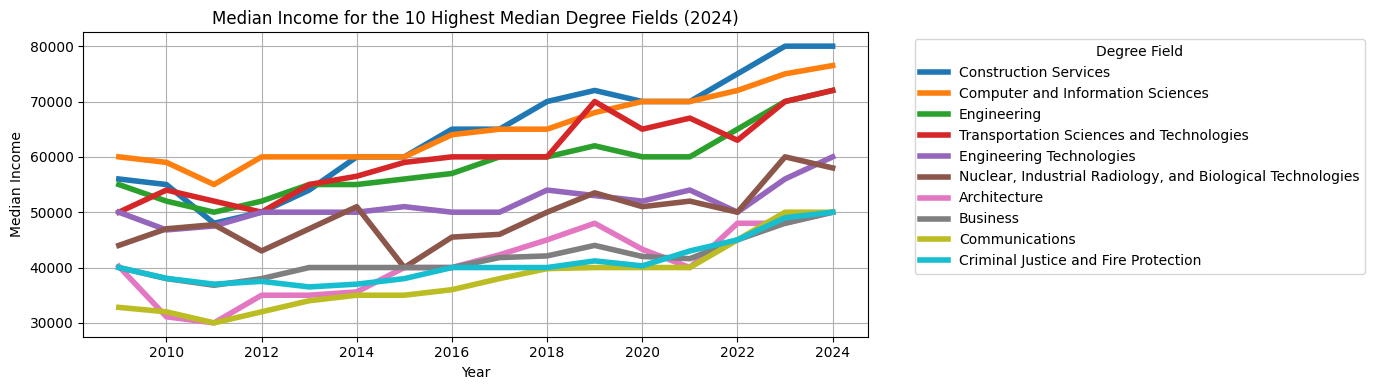

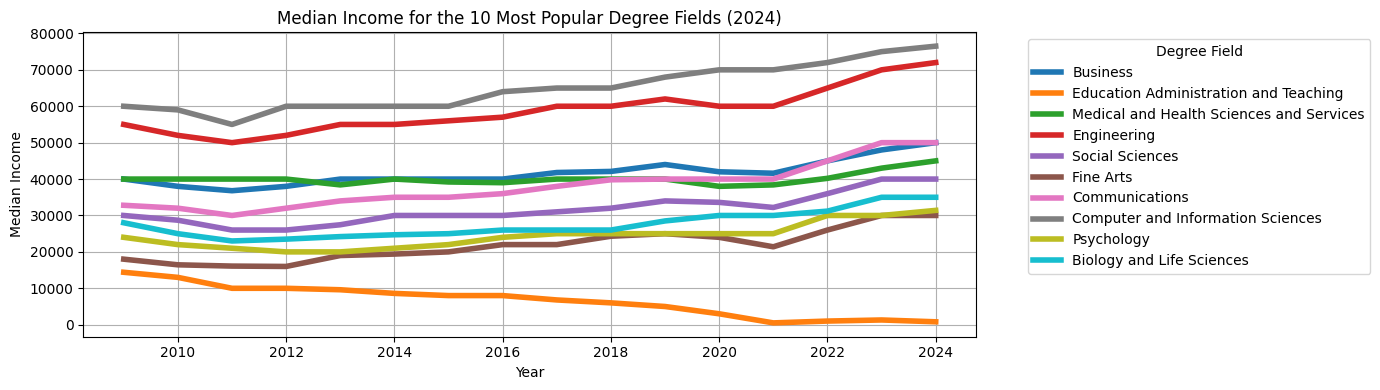

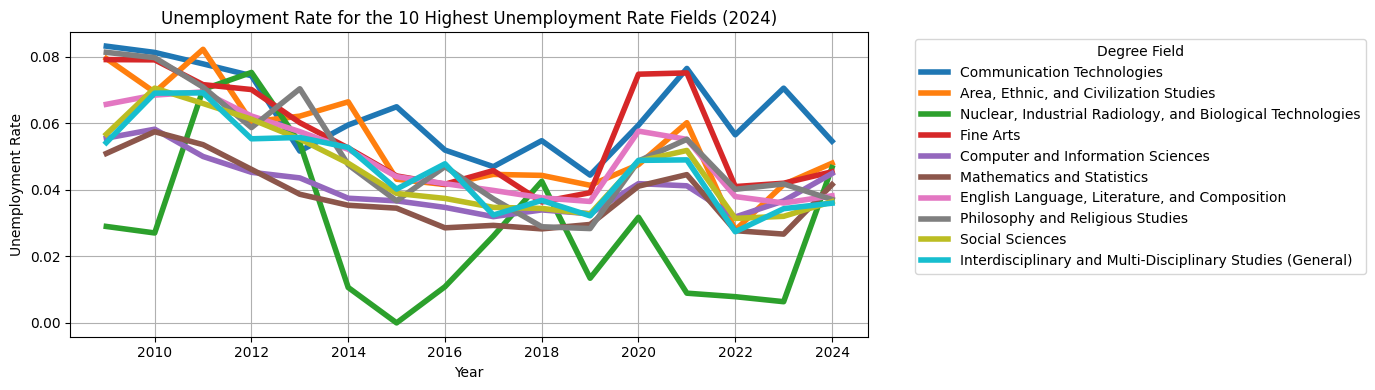

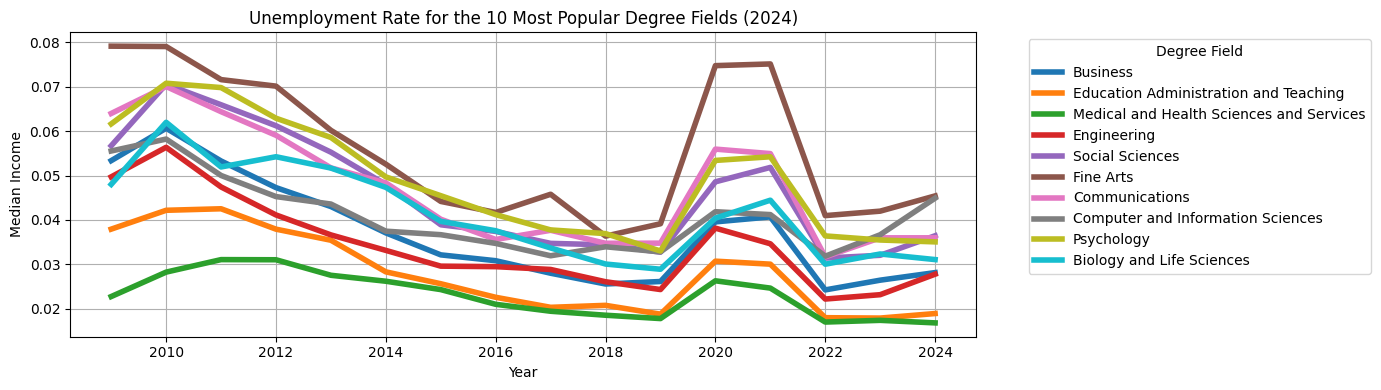

In [22]:
pivot_median= undergrad_grouped.pivot(index="YEAR", columns="FIELD_NAME", values="median_wage")
pivot_unemployment = undergrad_grouped.pivot(index="YEAR",columns="FIELD_NAME",values="unemployment_rate")
top10_median = ( pivot_median.loc[2024].nlargest(10) .index)
top10_unemployment= (pivot_unemployment.loc[2024].nlargest(10).index)
top10_count_median = (undergrad_grouped[undergrad_grouped["YEAR"] == 2024].nlargest(10, "count")["FIELD_NAME"])
top10_count_unemployment = (undergrad_grouped[undergrad_grouped["YEAR"] == 2024].nlargest(10, "count")["FIELD_NAME"])


figsize = (14,4)
plt.figure(figsize=figsize)
pivot_median[top10_median].plot(ax=plt.gca(),lw = 4)

plt.title("Median Income for the 10 Highest Median Degree Fields (2024)")
plt.xlabel("Year")
plt.ylabel("Median Income")
plt.legend(title="Degree Field", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=figsize)
pivot_median[top10_count_median].plot(ax = plt.gca(),lw = 4)

plt.title(f"Median Income for the 10 Most Popular Degree Fields (2024)")
plt.xlabel("Year")
plt.ylabel("Median Income")
plt.legend(title="Degree Field", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=figsize)
pivot_unemployment[top10_unemployment].plot(ax=plt.gca(),lw = 4)

plt.title("Unemployment Rate for the 10 Highest Unemployment Rate Fields (2024)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")
plt.legend(title="Degree Field", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize = figsize)
pivot_unemployment[top10_count_unemployment].plot(ax = plt.gca(),lw = 4)

plt.title(f"Unemployment Rate for the 10 Most Popular Degree Fields (2024)")
plt.xlabel("Year")
plt.ylabel("Median Income")
plt.legend(title="Degree Field", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
'''
pdfs = {}

for field, d in dfundergrad.groupby("FIELD_NAME"):
    incomes = d["INCWAGE"]
    incomes2 = incomes[incomes > 0] 
    shape, loc, scale = lognorm.fit(incomes2, floc=0)
    pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)
    pdfs[field] = pdf
    
    plt.figure(figsize=(2, 1))
    plt.hist(incomes, bins=30, density=True, alpha=0.6)
    x = np.linspace(incomes.min(), incomes.max(), 500)


    plt.title(field)
    plt.xlabel("Income")
    plt.ylabel("Density")
    plt.show()
    '''




'\npdfs = {}\n\nfor field, d in dfundergrad.groupby("FIELD_NAME"):\n    incomes = d["INCWAGE"]\n    incomes2 = incomes[incomes > 0] \n    shape, loc, scale = lognorm.fit(incomes2, floc=0)\n    pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)\n    pdfs[field] = pdf\n    \n    plt.figure(figsize=(2, 1))\n    plt.hist(incomes, bins=30, density=True, alpha=0.6)\n    x = np.linspace(incomes.min(), incomes.max(), 500)\n\n\n    plt.title(field)\n    plt.xlabel("Income")\n    plt.ylabel("Density")\n    plt.show()\n    '

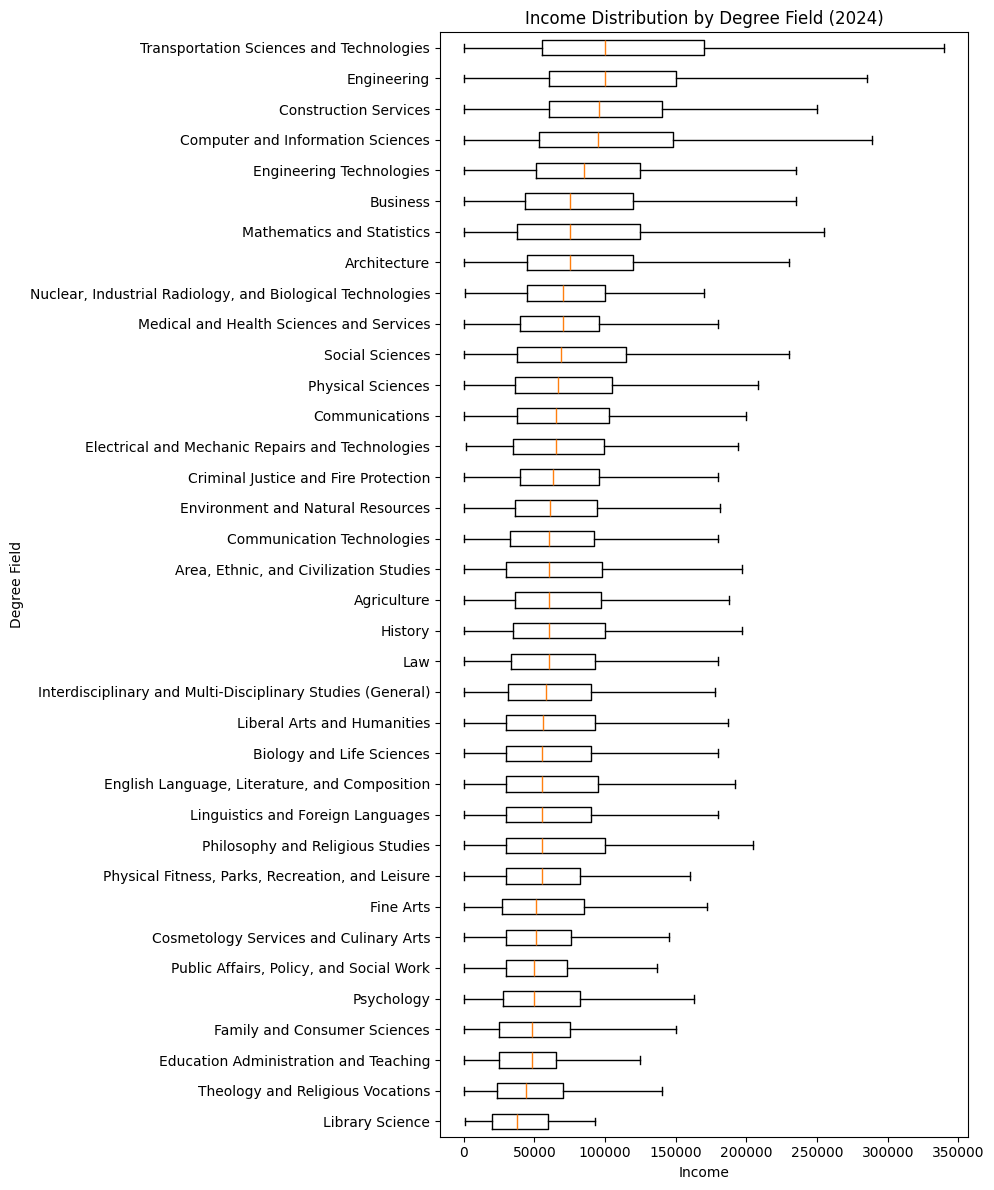

In [8]:
plot_df = undergrad2024[undergrad2024["INCWAGE"] > 0]

order = (plot_df.groupby("FIELD_NAME")["INCWAGE"].median().sort_values().index)

a = [ plot_df.loc[plot_df["FIELD_NAME"] == field, "INCWAGE"] for field in order]

plt.figure(figsize=(10, 12))

plt.boxplot(a,tick_labels=order, vert=False, showfliers=False)

plt.xlabel("Income")
plt.ylabel("Degree Field")
plt.title("Income Distribution by Degree Field (2024)")
plt.tight_layout()
plt.show()

In [9]:
grad_under2024_grouped = undergrad2024_grouped[["FIELD_NAME","median_wage","unemployment_rate"]].join(grad2024_grouped[["FIELD_NAME","median_wage","unemployment_rate"]], lsuffix = "_undergrad", rsuffix = "_grad")
grad_under2024_grouped["absdiff"] = (grad_under2024_grouped["median_wage_grad"]-grad_under2024_grouped["median_wage_undergrad"])
grad_under2024_grouped["%diff"] = grad_under2024_grouped["absdiff"] /(grad_under2024_grouped["median_wage_undergrad"])


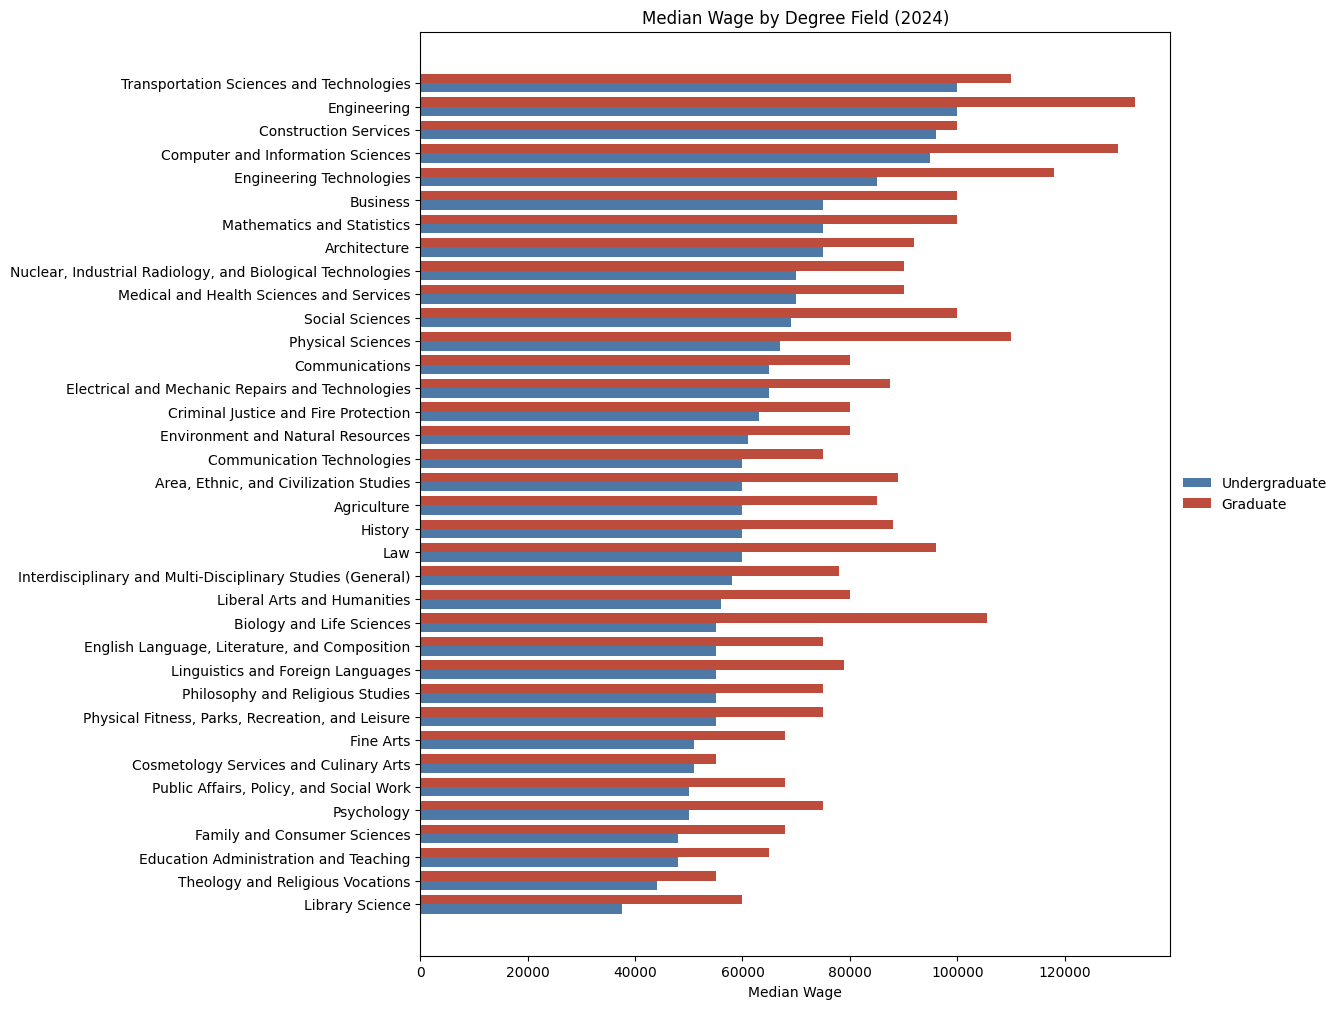

In [10]:
plot_df = grad_under2024_grouped.sort_values("median_wage_undergrad")

y = np.arange(len(plot_df))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(12, 12))

ax.barh(
    y - bar_height/2,
    plot_df["median_wage_undergrad"],
    height=bar_height,
    label="Undergraduate",
    color="#4E79A7"
)

ax.barh(
    y + bar_height/2,
    plot_df["median_wage_grad"],
    height=bar_height,
    label="Graduate",
    color="#BD4C3D"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["FIELD_NAME_undergrad"])
ax.set_xlabel("Median Wage")
ax.set_title("Median Wage by Degree Field (2024)")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

fig.subplots_adjust(right=0.75)
plt.show()

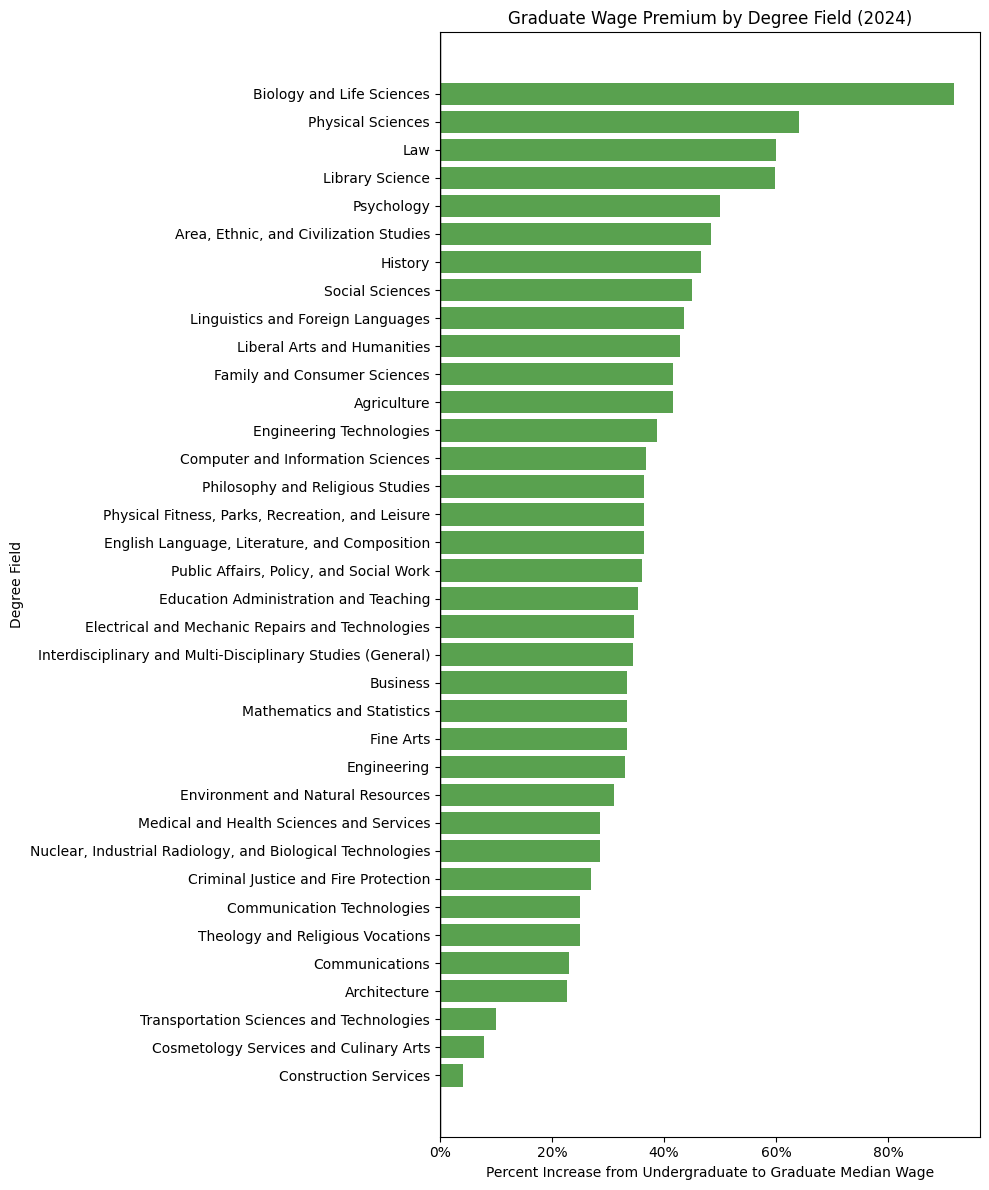

In [11]:
import matplotlib.ticker as mtick

plot_df = grad_under2024_grouped.sort_values("%diff")

plt.figure(figsize=(10, 12))

plt.barh(
    plot_df["FIELD_NAME_undergrad"],
    plot_df["%diff"],
    color="#59A14F"
)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xlabel("Percent Increase from Undergraduate to Graduate Median Wage")
plt.ylabel("Degree Field")
plt.title("Graduate Wage Premium by Degree Field (2024)")

plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

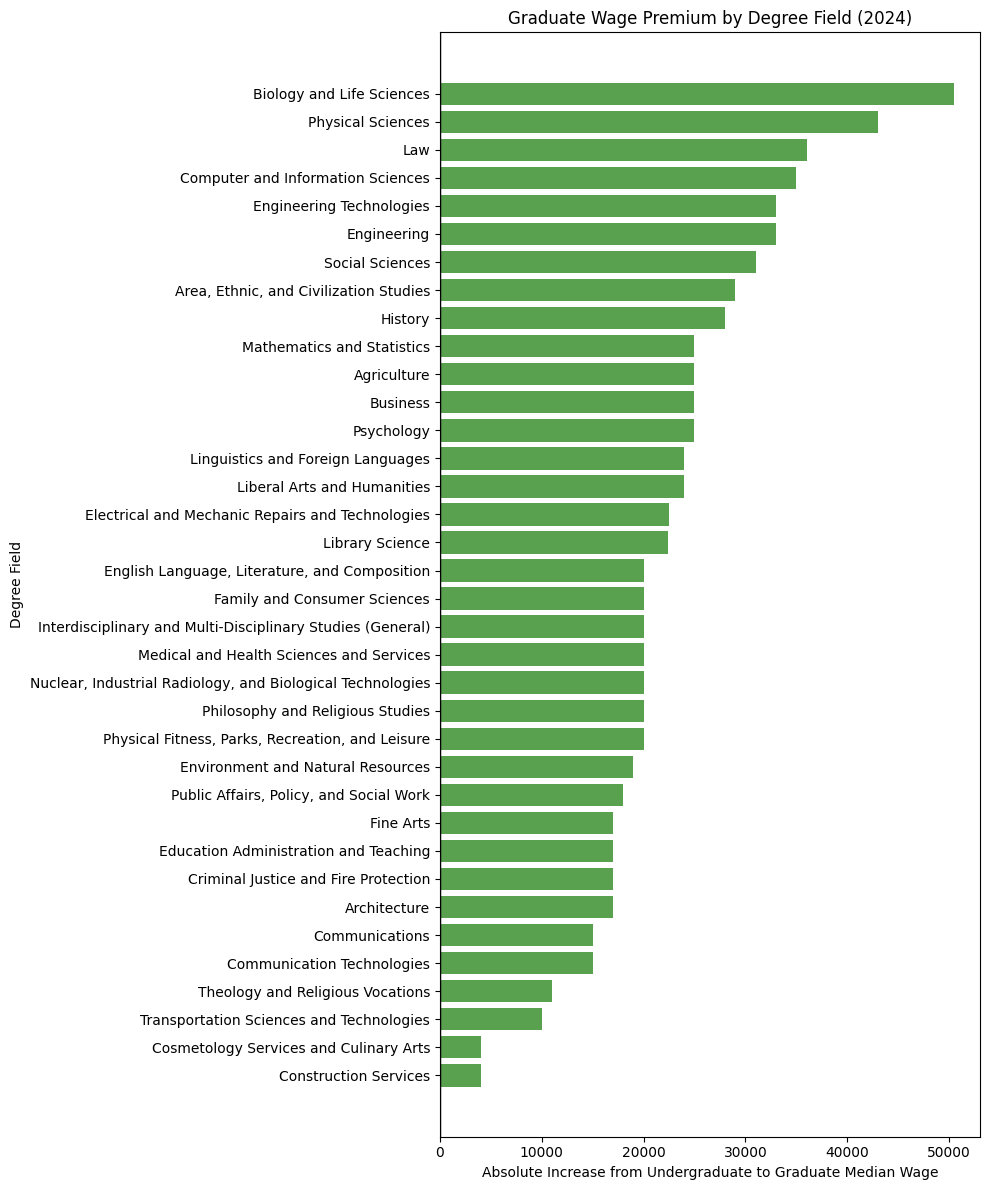

In [12]:


plot_df = grad_under2024_grouped.sort_values("absdiff")

plt.figure(figsize=(10, 12))

plt.barh(
    plot_df["FIELD_NAME_undergrad"],
    plot_df["absdiff"],
    color="#59A14F"
)

plt.xlabel("Absolute Increase from Undergraduate to Graduate Median Wage")
plt.ylabel("Degree Field")
plt.title("Graduate Wage Premium by Degree Field (2024)")

plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

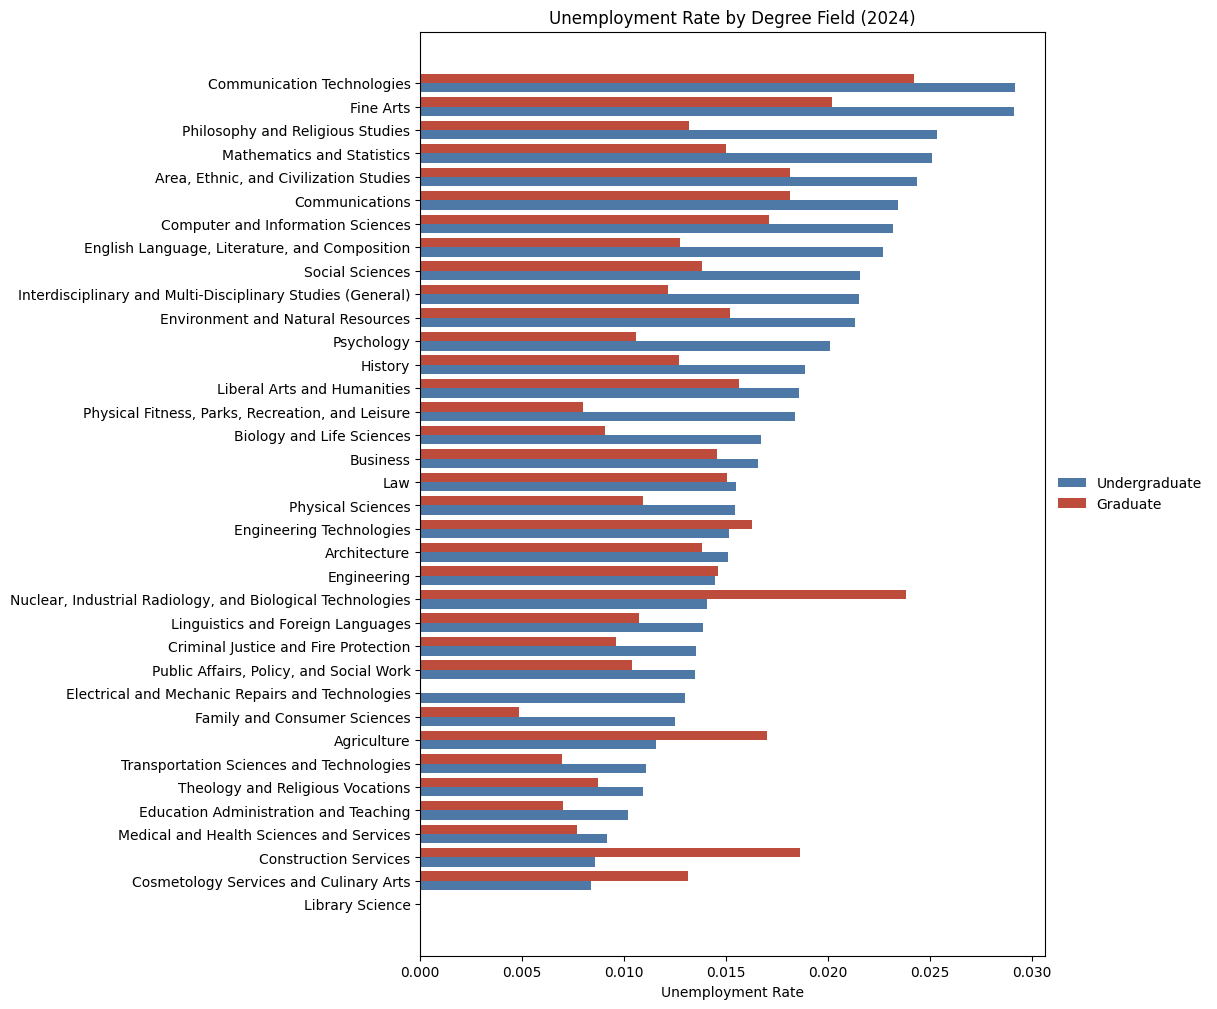

In [13]:
plot_df = grad_under2024_grouped.sort_values("unemployment_rate_undergrad")

y = np.arange(len(plot_df))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(
    y - bar_height/2,
    plot_df["unemployment_rate_undergrad"],
    height=bar_height,
    label="Undergraduate",
    color="#4E79A7"
)

ax.barh(
    y + bar_height/2,
    plot_df["unemployment_rate_grad"],
    height=bar_height,
    label="Graduate",
    color="#BD4C3D"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["FIELD_NAME_undergrad"])
ax.set_xlabel("Unemployment Rate")
ax.set_title("Unemployment Rate by Degree Field (2024)")

ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

fig.subplots_adjust(right=0.75)
plt.show()

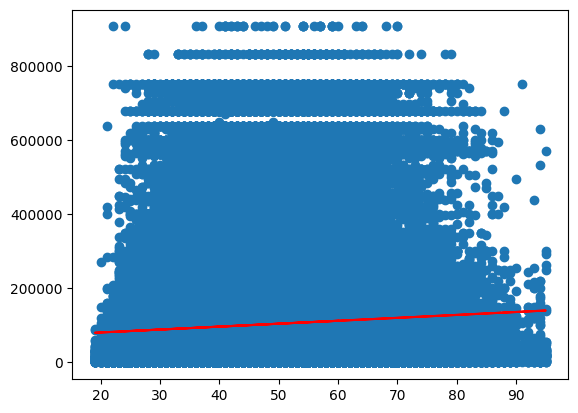

In [ ]:


x = all2024["AGE"]
y = all2024["INCWAGE"]

plt.scatter(x,y)
model = stats.linregress(x, y)

plt.plot(x, model.intercept + model.slope * x, color="red", label="Fit Line")

plt.show()


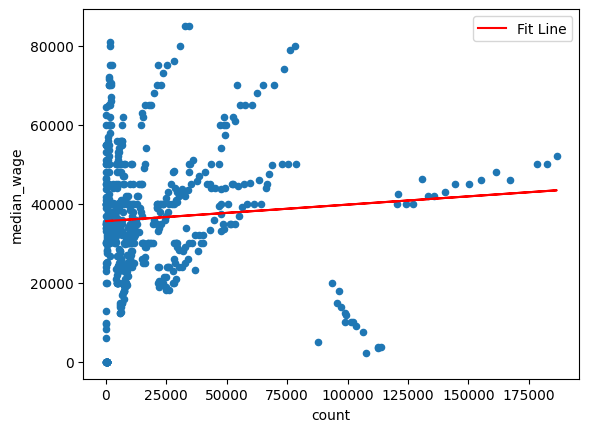

In [ ]:
grouped.plot.scatter(x="count", y="median_wage")

x = grouped["AGE"]
y = grouped["median_wage"]

model = stats.linregress(x, y)

plt.plot(x, model.intercept + model.slope * x, color="red", label="Fit Line")

plt.legend()
plt.show()
